# Build A Basic Chatbot With Langgraph(GRAPH API)

In [1]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list, add_messages]

graph_builder = StateGraph(State)

In [3]:
graph_builder

In [4]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
from langchain_groq import ChatGroq

llm=ChatGroq(model="openai/gpt-oss-20b")

In [6]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.5', 'langchain': '1.4.2'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000017A600186E0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000017A60019160>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [7]:
### Node functionality
def chatbot(state:State):
    return {"messages": [llm.invoke(state["messages"])]}

In [8]:
graph_builder = StateGraph(State)

## Adding node
graph_builder.add_node("llmchatbot", chatbot)

## Adding edges
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

## Compile the graph
graph = graph_builder.compile()

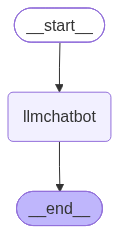

In [9]:
## Visualize the graph
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [10]:
response = graph.invoke({"messages": "Hi"})

In [11]:
response["messages"][-1].content

'Hello! How can I help you today?'

In [12]:
for event in graph.stream({"messages": "Hi How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

Hello! I’m doing great—thanks for asking. How can I help you today?


### Chatbot with Tool

In [13]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results = 2)
tools = [tool]
tool.invoke("what is langgraph?")

{'query': 'what is langgraph?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? | IBM',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. [...] Agent systems: LangGraph provides a framework for building agent-based systems, which can be used in applications such as robotics, autonomous vehicles or video games.\n\nLLM applications: By using LangGraph’s capabilities, developers can build more sophisticated AI models that learn and improve over time. Norwe

In [17]:
## Custom function
def multiply(a:int, b:int)->int:
    """ Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a * b


In [18]:
tools = [tool, multiply]

In [19]:
llm_with_tools = llm.bind_tools(tools)

In [20]:
llm_with_tools

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.5', 'langchain': '1.4.2'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000017A600186E0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000017A60019160>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and 

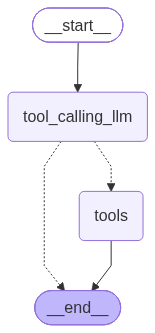

In [26]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [28]:
response = graph.invoke({"messages": "what is the recent ai news"})

In [29]:
response["messages"][-1].content

'{"query": "recent AI news 2026 September 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.pwc.com/gx/en/news-room/press-releases/2026/companies-risk-losing-ai-savvy-employees.html", "title": "Companies risk losing their most AI-savvy employees while leaving majority behind | PwC", "content": "LONDON, 29 September 2026 – A growing AI skills divide is creating a diverging workforce, with the majority of workers at risk of being left behind as access to learning and development falls – even as AI use and the pace of workplace change accelerate.", "score": 0.8719229, "raw_content": null, "published_date": "Tue, 29 Sep 2026 06:00:00 GMT", "id": "321f1a-00"}, {"url": "https://www.theverge.com/ai-artificial-intelligence/1001681/openai-devday-2026-biggest-news-announcements", "title": "OpenAI DevDay 2026: The biggest news and announcements | The Verge", "content": "It’s OpenAI’s turn in the fall tech events calendar. The company is hosting its

In [30]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is the recent ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_34a16f61-d8f5-491c-99cf-46b14108ff4c)
 Call ID: fc_34a16f61-d8f5-491c-99cf-46b14108ff4c
  Args:
    query: recent AI news 2026 September 2026
    search_depth: basic
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news 2026 September 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.pwc.com/gx/en/news-room/press-releases/2026/companies-risk-losing-ai-savvy-employees.html", "title": "Companies risk losing their most AI-savvy employees while leaving majority behind | PwC", "content": "LONDON, 29 September 2026 – A growing AI skills divide is creating a diverging workforce, with the majority of workers at risk of 

In [31]:
response = graph.invoke({"messages": "what is 7 * 8"})

In [32]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is 7 * 8
================================== Ai Message ==================================

7 × 8 = 56


In [33]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_953e33c0-e82b-49d5-aebb-b0d10814a809)
 Call ID: fc_953e33c0-e82b-49d5-aebb-b0d10814a809
  Args:
    query: latest AI news
    search_depth: basic
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://foxbaltimore.com/news/nation-world/openai-pulls-new-model-back-as-ai-industry-confronts-growing-safety-concerns-gpt-astra-artificial-intelligence-rogue-models-hacks-cybersecurity", "title": "OpenAI pulls new model back as AI industry confronts growing safety concerns", "content": "After its disclosure that its system had hacked into Hugging Face earl

### ReAct Agent Architecture


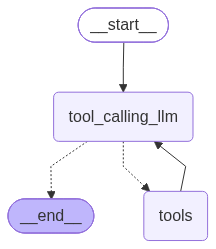

In [35]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [36]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_04137103-8c46-4b68-854b-4cc633790d0b)
 Call ID: fc_04137103-8c46-4b68-854b-4cc633790d0b
  Args:
    query: latest AI news 2026
    search_depth: advanced
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.googlecloudpresscorner.com/2026-09-29-The-Ohio-State-University-and-Google-Partner-to-Accelerate-Research-and-AI-Fluency", "title": "The Ohio State University and Google Partner to Accelerate Research and AI Fluency - Sep 29, 2026", "content": "Student-focused initiatives include:\n\n Increasing technology access: Through Google for 

### Adding Memory in Agentic Graph

In [37]:
response=graph.invoke({"messages":"Hello My name is Anees."})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello My name is Anees.
================================== Ai Message ==================================

Hello Anees! 👋 How can I help you today?


In [38]:
response=graph.invoke({"messages":"What is my name"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is my name
================================== Ai Message ==================================

I don’t have any information about your name, so I can’t answer that. If you’d like me to know it, feel free to tell me!


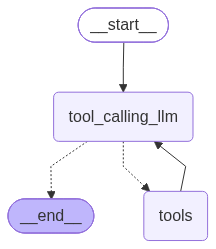

In [39]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [42]:
config={"configurable": {"thread_id": "1"}}

response = graph.invoke({"messages": "Hi my name is Anees"}, config=config)

response

{'messages': [HumanMessage(content='Hi my name is Anees', additional_kwargs={}, response_metadata={}, id='dc074ba2-6a4c-490b-912e-4f1d7b78fb4c'),
  AIMessage(content='Hello Anees! 👋 How can I help you today?', additional_kwargs={'reasoning_content': 'The user says: "Hi my name is Anees". This is a greeting. We should respond politely, maybe ask how we can help.'}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 348, 'total_tokens': 400, 'completion_time': 0.054235727, 'completion_tokens_details': {'reasoning_tokens': 30}, 'prompt_time': 0.018117012, 'prompt_tokens_details': None, 'queue_time': 0.208942204, 'total_time': 0.072352739}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_409ec51fe1', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0f02b-759b-7313-8ade-84c9b2470411-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 348, 'output_tokens': 52, 'total

In [43]:
response["messages"][-1].content

'Hello Anees! 👋 How can I help you today?'

In [44]:
response = graph.invoke({"messages": "Hey what is my name?"}, config=config)

print(response["messages"][-1].content)

Your name is Anees.


In [45]:
response = graph.invoke({"messages": "Hey Do you remember me?"}, config=config)

print(response["messages"][-1].content)

I don’t have long‑term memory of past conversations, but from this session you told me your name is Anees. How can I help you today?


### Streaming
 - Methods: .stream() and astream()

These methods are sync and async methods for streaming back results.
Additional parameters in streaming modes for graph state

 - values : This streams the full state of the graph after each node is called.
 - updates : This streams updates to the state of the graph after each node is called.

In [46]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()



In [47]:
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

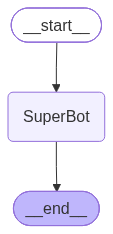

In [48]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile(checkpointer=memory)


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [49]:
## Invocation

config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({'messages':"Hi,My name is Anees And I like Math"},config)

{'messages': [HumanMessage(content='Hi,My name is Anees And I like Math', additional_kwargs={}, response_metadata={}, id='a3329cad-5e35-433e-9992-fdffbb1987e4'),
  AIMessage(content='Hello, Anees! 👋 It’s great to meet someone who loves math. What areas of mathematics do you enjoy the most? Algebra, geometry, calculus, number theory, or maybe something else? Let me know, and we can dive into some interesting problems or concepts together!', additional_kwargs={'reasoning_content': 'The user says "Hi,My name is Anees And I like Math". We should respond politely, greet them, ask about math interests, maybe offer help. No policy issues. Just respond.'}, response_metadata={'token_usage': {'completion_tokens': 107, 'prompt_tokens': 82, 'total_tokens': 189, 'completion_time': 0.118566603, 'completion_tokens_details': {'reasoning_tokens': 41}, 'prompt_time': 0.004572964, 'prompt_tokens_details': None, 'queue_time': 0.34696339, 'total_time': 0.123139567}, 'model_name': 'openai/gpt-oss-20b', 'sys

In [50]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Anees And I like math."},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='Hello Anees! 👋 It’s great to meet someone who loves math. What area of math are you most excited about—algebra, geometry, calculus, number theory, or something else? Or maybe you have a math problem or project you’d like to chat about? Let me know!', additional_kwargs={'reasoning_content': 'We have a conversation: user says "Hi, My name is Anees And I like math." There\'s no specific question. According to policy, we should respond with a friendly greeting, acknowledging the name, and perhaps ask about math interests or ask what they\'d like to discuss. It\'s a normal conversation. No policy conflict. We can respond with a friendly greeting and ask what math they\'d like to talk about.'}, response_metadata={'token_usage': {'completion_tokens': 151, 'prompt_tokens': 83, 'total_tokens': 234, 'completion_time': 0.160251757, 'completion_tokens_details': {'reasoning_tokens': 82}, 'prompt_time': 0.004064159, 'prompt_tokens_details': None, 'queue_

In [51]:
for chunk in graph_builder.stream({'messages':"Hi,My name is Anees And I like math."},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Anees And I like math.', additional_kwargs={}, response_metadata={}, id='c60cc187-bf06-49f9-8ef0-0d060a0dc8be'), AIMessage(content='Hello Anees! 👋 It’s great to meet someone who loves math. What area of math are you most excited about—algebra, geometry, calculus, number theory, or something else? Or maybe you have a math problem or project you’d like to chat about? Let me know!', additional_kwargs={'reasoning_content': 'We have a conversation: user says "Hi, My name is Anees And I like math." There\'s no specific question. According to policy, we should respond with a friendly greeting, acknowledging the name, and perhaps ask about math interests or ask what they\'d like to discuss. It\'s a normal conversation. No policy conflict. We can respond with a friendly greeting and ask what math they\'d like to talk about.'}, response_metadata={'token_usage': {'completion_tokens': 151, 'prompt_tokens': 83, 'total_tokens': 234, 'completion_time'

In [52]:
# Create a thread
config = {"configurable": {"thread_id": "4"}}
for chunk in graph_builder.stream({'messages':"Hi,My name is Anees And I like math."},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='Hi Anees! 👋 It’s great to meet someone who loves math. What kind of math topics do you enjoy the most—algebra, geometry, number theory, calculus, or maybe something else? If you have a favorite problem or a concept you’re curious about, feel free to share!', additional_kwargs={'reasoning_content': 'We have a conversation: user says "Hi,My name is Anees And I like math." There\'s no explicit instruction, but the user is introducing themselves. We should respond warmly, ask about math interests. The policy says we can talk about math. No disallowed content. So respond friendly.'}, response_metadata={'token_usage': {'completion_tokens': 131, 'prompt_tokens': 83, 'total_tokens': 214, 'completion_time': 0.136165907, 'completion_tokens_details': {'reasoning_tokens': 61}, 'prompt_time': 0.004201092, 'prompt_tokens_details': None, 'queue_time': 0.309211174, 'total_time': 0.140366999}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_e5

In [53]:
for chunk in graph_builder.stream({'messages':"I also like Physics."},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='That’s awesome—math and physics go hand‑in‑hand! 🚀\n\n- **Math:** Do you enjoy pure math (like number theory, abstract algebra, topology) or applied math (differential equations, statistics, numerical methods)?\n- **Physics:** Are you into classical mechanics, electromagnetism, quantum mechanics, relativity, thermodynamics, or something else?\n\nIf you have a particular problem, concept, or recent discovery that’s caught your eye, let me know! I’m happy to dive into equations, explore theories, or just chat about the beauty of the universe.', additional_kwargs={'reasoning_content': 'User says they like math and physics. We should respond, maybe ask what topics or ask about favorite area. Probably ask about what they like or what they want to discuss.'}, response_metadata={'token_usage': {'completion_tokens': 165, 'prompt_tokens': 159, 'total_tokens': 324, 'completion_time': 0.176767009, 'completion_tokens_details': {'reasoning_tokens': 36},

In [54]:
for chunk in graph_builder.stream({'messages':"I also like Physics."},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Anees And I like math.', additional_kwargs={}, response_metadata={}, id='53f4823d-b421-496b-b7c5-c25a63aaccc7'), AIMessage(content='Hi Anees! 👋 It’s great to meet someone who loves math. What kind of math topics do you enjoy the most—algebra, geometry, number theory, calculus, or maybe something else? If you have a favorite problem or a concept you’re curious about, feel free to share!', additional_kwargs={'reasoning_content': 'We have a conversation: user says "Hi,My name is Anees And I like math." There\'s no explicit instruction, but the user is introducing themselves. We should respond warmly, ask about math interests. The policy says we can talk about math. No disallowed content. So respond friendly.'}, response_metadata={'token_usage': {'completion_tokens': 131, 'prompt_tokens': 83, 'total_tokens': 214, 'completion_time': 0.136165907, 'completion_tokens_details': {'reasoning_tokens': 61}, 'prompt_time': 0.004201092, 'prompt_tokens

In [55]:
config = {"configurable": {"thread_id": "5"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is Anees and I like physics"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Anees and I like physics']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '01a0f03d-b4c0-7bb3-ab60-88d8fbf53aca', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is Anees and I like physics', additional_kwargs={}, response_metadata={}, id='ecb7b509-1191-4e04-a3d6-77022bdd3232')]}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '01a0f03d-b4c3-7c20-93db-39199c907e5b', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:7b3a3db2-65d9-4c8d-ac77-df1a9817e505'}, 'parent_ids': ['01a0f03d-b4c0-7bb3-ab60-88d8fbf53aca']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMessage(